# FDSI benchmark: apply sim_04 single-objective config

Takes the frozen hyperparameters from the single-objective optimisation in
`sim_04_kl_to_cal_iterN.ipynb` and applies them to all 100 FDSI recordings
(5 subjects × 5 conditions × 4 SNR levels).  
Evaluation follows the same RoA structure as sim_04.  
For triangular contractions, RoA is also reported per temporal phase:
first isometric → triangular ramp → last isometric.

**Config summary**
- `wh_mode = 'kl_to_cal'`
- `max_iter_b = 5`
- `max_rel_delta_v = 5.1069e-03`
- `max_rel_delta_b = 1.1567e-02`
- `centroid_momentum = 8.0515e-01`

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.utils import rate_of_agreement_paired

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)

In [2]:
# ── Run control ───────────────────────────────────────────────────────────────
# Set RUN_DECOMP = False to reload cached results without re-running adapt_decomp.
RUN_DECOMP  = True

FDSI_ROOT   = Path('C:/Users/Irene/Documents/work_local/muniverse/outputs/fdsi_benchmark')
RESULTS_DIR = Path('..', 'data', 'fdsi_results', 'apply_best_config')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset constants ─────────────────────────────────────────────────────────
FS                = 2048
CAL_END           = int(5.0 * FS)   # 10240 — calibration window end (samples)
SUBJECTS          = [f'sub-{i:02d}' for i in range(1, 6)]
CONDITIONS        = ['triangular-ramp40s', 'triangular-ramp20s',
                     'triangular-ramp10s', 'triangular-ramp5s', 'staircase']
TRIANGULAR        = [c for c in CONDITIONS if 'triangular' in c]
SNR_LEVELS        = [30, 25, 20, 15]
ANGLE_ISO_THR_DEG = 2.0   # |angle| < threshold deg → isometric

# ── Frozen hyperparameters from sim_04 single-objective optimisation ──────────
BEST_CONFIG = {
    # Fixed settings (matching sim_04 base_config)
    'ext_fact':          12,          # FDSI uses R=12 (vs. 10 in example data)
    'adapt_wh':          True,
    'adapt_sv':          True,
    'adapt_sd':          True,
    'wh_mode':           'kl_to_cal',
    'contrast_scope':    'spike_based',
    'extension_method':  'block',
    'wh_b_coupling':     False,
    'max_iter_b':        5,
    'log_loss':          True,
    'device':            'cpu',
    'trace_check':       True,
    # Optimised parameters
    'max_rel_delta_v':   5.1069e-03,
    'max_rel_delta_b':   1.1567e-02,
    'centroid_momentum': 8.0515e-01,
}

print(f'FDSI root: {FDSI_ROOT}')
print(f'Results:   {RESULTS_DIR}')
print(f'Recordings: {len(SUBJECTS)} subs × {len(CONDITIONS)} conds × {len(SNR_LEVELS)} SNR = '
      f'{len(SUBJECTS)*len(CONDITIONS)*len(SNR_LEVELS)}')

FDSI root: C:\Users\Irene\Documents\work_local\muniverse\outputs\fdsi_benchmark
Results:   ..\data\fdsi_results\apply_best_config
Recordings: 5 subs × 5 conds × 4 SNR = 100


## 1. Helper functions

In [3]:
def load_fdsi_recording(root, sub, cond, snr):
    """Load one FDSI recording into tensors shaped for AdaptDecomp.

    Returns a dict with all calibration tensors, the adaptation EMG,
    biomechanical signals, and ground-truth spike trains.
    """
    root = Path(root)

    # ── Calibration package ───────────────────────────────────────────────────
    cal_path = (root / 'calibrated_units_block' / sub
                / f'{sub}_FDSI_{cond}_snr{snr}dB_calibrated_units.npz')
    cal = np.load(cal_path)

    n_hq         = cal['mu_filters'].shape[1]
    est_unit_ids = cal['est_unit_ids']

    # Shape conversions (file is channels/units-first; API expects samples-first)
    whitening      = torch.from_numpy(cal['whitening'].astype(np.float32))          # (1200,1200)
    sep_vectors    = torch.from_numpy(cal['mu_filters'].T.astype(np.float32))       # (n_hq,1200)
    base_centroids = torch.from_numpy(cal['centroids'][:, 0].astype(np.float32))   # (n_hq,)
    spike_centroids = torch.from_numpy(cal['centroids'][:, 1].astype(np.float32))  # (n_hq,)
    emg_calib      = torch.from_numpy(cal['emg_cal'].T.astype(np.float32))          # (10240,100)
    ipts_calib     = torch.from_numpy(cal['sources'].T.astype(np.float32))          # (10240,n_hq)

    # Binary calibration spikes (10240, n_hq) from per-unit index arrays
    spikes_cal_np = np.zeros((CAL_END, n_hq), dtype=np.float32)
    for i, uid in enumerate(est_unit_ids):
        key = f'spikes_unit{uid}'
        if key in cal:
            idx = cal[key].astype(int)
            idx = idx[(idx >= 0) & (idx < CAL_END)]
            spikes_cal_np[idx, i] = 1.0
    spikes_calib = torch.from_numpy(spikes_cal_np)

    gt_unit_labels = cal['gt_unit_labels']   # maps HQ unit index → GT MU index

    # ── Noisy EMG (adaptation segment) ───────────────────────────────────────
    emg_path  = root / 'data' / sub / 'noisy' / f'{sub}_FDSI_{cond}_snr{snr}dB_emg.npz'
    emg_full  = np.load(emg_path)['emg']                                 # (n_samples,100)
    emg_adapt = torch.from_numpy(emg_full[CAL_END:].astype(np.float32))  # (n_adapt,100)

    # ── Biomechanical signals (adaptation segment) ────────────────────────────
    clean_dir    = root / 'data' / sub / 'clean'
    angle_adapt  = np.load(clean_dir / f'{sub}_FDSI_{cond}_angle.npz')['angle'][CAL_END:]
    effort_adapt = np.load(clean_dir / f'{sub}_FDSI_{cond}_effort.npz')['effort'][CAL_END:]

    # ── Ground-truth spike trains ─────────────────────────────────────────────
    spikes_obj = np.load(
        clean_dir / f'{sub}_FDSI_{cond}_spikes.npz', allow_pickle=True
    )['spikes']

    return {
        'whitening':       whitening,
        'sep_vectors':     sep_vectors,
        'base_centroids':  base_centroids,
        'spike_centroids': spike_centroids,
        'emg_calib':       emg_calib,
        'ipts_calib':      ipts_calib,
        'spikes_calib':    spikes_calib,
        'emg_adapt':       emg_adapt,
        'angle_adapt':     angle_adapt,
        'effort_adapt':    effort_adapt,
        'spikes_obj':      spikes_obj,
        'gt_unit_labels':  gt_unit_labels,
        'n_hq':            n_hq,
    }

In [4]:
def build_gt_binary(spikes_obj, gt_unit_labels, n_adapt):
    """Convert GT spike object array to a binary matrix (n_adapt, n_hq).

    Spike indices are re-indexed to the adaptation segment (sample 0 = CAL_END).
    gt_unit_labels[i] is the GT MU index for adapt_decomp output unit i.
    """
    n_hq   = len(gt_unit_labels)
    gt_bin = np.zeros((n_adapt, n_hq), dtype=np.float32)
    for i, gt_idx in enumerate(gt_unit_labels):
        gt_samples    = np.asarray(spikes_obj[gt_idx])
        adapt_samples = gt_samples[gt_samples >= CAL_END] - CAL_END
        adapt_samples = adapt_samples[adapt_samples < n_adapt].astype(int)
        gt_bin[adapt_samples, i] = 1.0
    return gt_bin

In [5]:
def detect_triangular_phases(angle_adapt):
    """Split adaptation segment into first isometric / ramp / last isometric.

    Returns a dict with sample-index arrays for each phase and the
    ramp_start / ramp_end boundaries (useful for plotting).
    """
    n      = len(angle_adapt)
    is_iso = np.abs(angle_adapt) < ANGLE_ISO_THR_DEG
    idx    = np.arange(n)

    ramp_start = int(np.argmax(~is_iso))           # first non-isometric sample
    ramp_end   = n - 1 - int(np.argmax(~is_iso[::-1]))  # last non-isometric sample

    first_iso = idx[(idx < ramp_start) & is_iso]
    ramp      = np.arange(ramp_start, ramp_end + 1)
    last_iso  = idx[(idx > ramp_end) & is_iso]

    return {
        'first_iso':  first_iso,
        'ramp':       ramp,
        'last_iso':   last_iso,
        'ramp_start': ramp_start,
        'ramp_end':   ramp_end,
    }


def compute_roa_subset(gt_bin, pred_spikes, idx):
    """RoA for a temporal subset of an adaptation-segment recording.

    Returns per-unit RoA array; NaN if the subset is empty.
    """
    if len(idx) == 0:
        return np.full(gt_bin.shape[1], np.nan)
    roa, _, _ = rate_of_agreement_paired(
        gt_bin[idx], pred_spikes[idx], fs=FS, tol_spike_ms=2
    )
    return roa

## 2. Run adapt_decomp across all 100 recordings

Results are cached as `.npz` files so the notebook can be re-run with
`RUN_DECOMP = False` to skip recomputation.

In [6]:
results = {}

pbar = tqdm(
    total=len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS),
    desc='adapt_decomp',
)

for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            key        = (sub, cond, snr)
            cache_dir  = RESULTS_DIR / sub / cond
            cache_dir.mkdir(parents=True, exist_ok=True)
            cache_path = cache_dir / f'snr{snr}dB_spikes.npz'

            if not RUN_DECOMP and cache_path.exists():
                cached = np.load(cache_path)
                data   = load_fdsi_recording(FDSI_ROOT, sub, cond, snr)
                n_adapt = len(data['angle_adapt'])
                results[key] = {
                    'spikes':      cached['spikes'],
                    'gt_bin':      build_gt_binary(data['spikes_obj'],
                                                   data['gt_unit_labels'], n_adapt),
                    'angle_adapt': data['angle_adapt'],
                    'n_hq':        data['n_hq'],
                }
            else:
                data = load_fdsi_recording(FDSI_ROOT, sub, cond, snr)

                cfg = Config()
                for k, v in BEST_CONFIG.items():
                    setattr(cfg, k, v)

                dec = AdaptDecomp(
                    emg             = data['emg_adapt'].clone(),
                    whitening       = data['whitening'].clone(),
                    sep_vectors     = data['sep_vectors'].clone(),
                    base_centroids  = data['base_centroids'].clone(),
                    spike_centroids = data['spike_centroids'].clone(),
                    emg_calib       = data['emg_calib'].clone(),
                    ipts_calib      = data['ipts_calib'].clone(),
                    spikes_calib    = data['spikes_calib'].clone(),
                    preprocess      = False,
                    config          = cfg,
                )
                outputs  = dec.run()
                spikes_np = outputs['spikes'].numpy()   # (n_adapt, n_hq)
                n_adapt   = len(data['angle_adapt'])

                np.savez_compressed(cache_path, spikes=spikes_np)

                results[key] = {
                    'spikes':      spikes_np,
                    'gt_bin':      build_gt_binary(data['spikes_obj'],
                                                   data['gt_unit_labels'], n_adapt),
                    'angle_adapt': data['angle_adapt'],
                    'n_hq':        data['n_hq'],
                }

            pbar.update(1)

pbar.close()
print(f'Done. {len(results)} recordings processed.')

adapt_decomp:   0%|          | 0/100 [00:00<?, ?it/s]

Done. 100 recordings processed.


## 3. Overall RoA — all conditions and SNR levels

In [7]:
rows = []
for (sub, cond, snr), res in results.items():
    roa, _, _ = rate_of_agreement_paired(
        res['gt_bin'], res['spikes'], fs=FS, tol_spike_ms=2
    )
    for u, r in enumerate(roa):
        rows.append({'sub': sub, 'condition': cond, 'snr': snr, 'unit': u, 'roa': float(r)})

df = pd.DataFrame(rows)
df['roa_pct'] = df['roa'] * 100

print('Mean RoA (%) per condition and SNR — averaged across subjects and units:')
print(
    df.groupby(['condition', 'snr'])['roa_pct']
    .agg(['mean', 'std'])
    .round(2)
    .to_string()
)

Mean RoA (%) per condition and SNR — averaged across subjects and units:
                         mean    std
condition          snr              
staircase          15   40.29  24.49
                   20   40.28  15.11
                   25   37.94  16.73
                   30   35.24  17.16
triangular-ramp10s 15   46.77  23.94
                   20   40.69  18.13
                   25   39.68  18.02
                   30   37.60  14.97
triangular-ramp20s 15   46.99  21.99
                   20   44.14  16.70
                   25   39.89  16.29
                   30   40.28  16.97
triangular-ramp40s 15   44.29  18.82
                   20   45.53  16.73
                   25   41.95  15.77
                   30   40.20  16.35
triangular-ramp5s  15   52.27  23.30
                   20   44.72  17.95
                   25   41.52  17.82
                   30   37.92  16.26


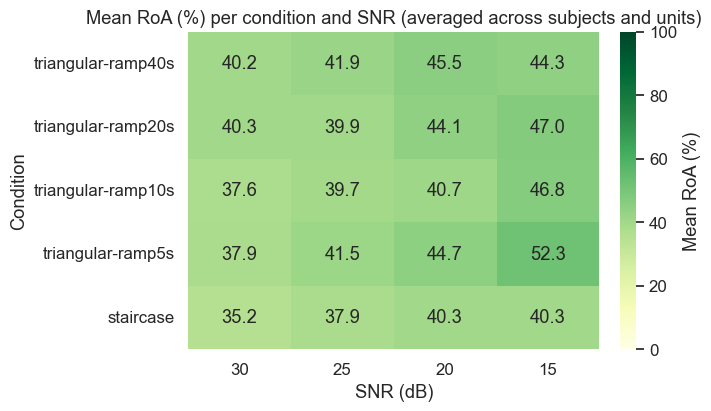

In [8]:
# Heatmap: mean RoA per condition (rows) × SNR (columns)
pivot = df.groupby(['condition', 'snr'])['roa_pct'].mean().unstack('snr')
pivot = pivot.reindex(index=CONDITIONS, columns=SNR_LEVELS)

fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlGn',
    vmin=0, vmax=100, ax=ax,
    cbar_kws={'label': 'Mean RoA (%)'},
)
ax.set(title='Mean RoA (%) per condition and SNR (averaged across subjects and units)',
       xlabel='SNR (dB)', ylabel='Condition')
plt.show()

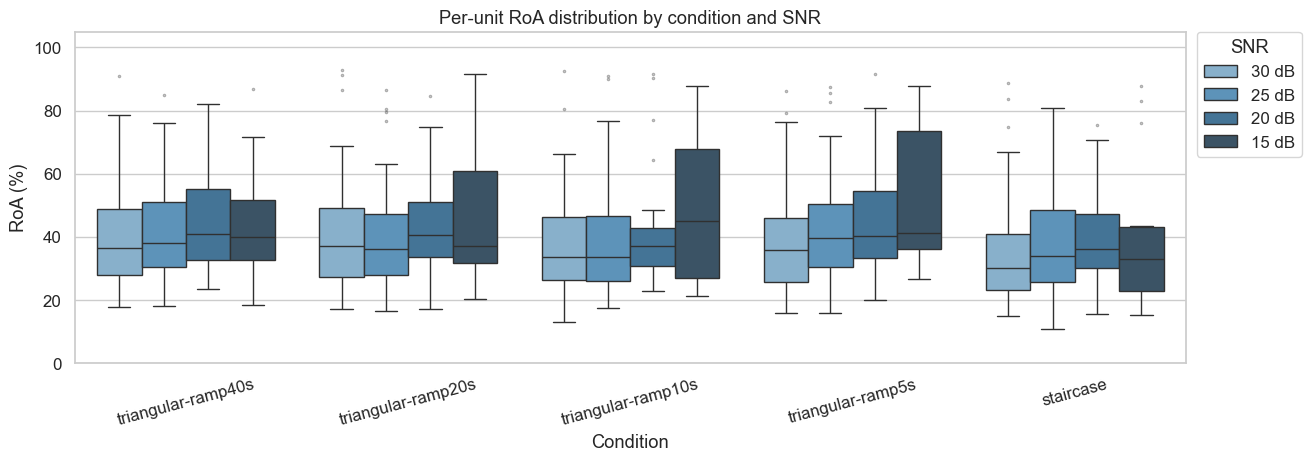

In [9]:
# Box plot: per-unit RoA distribution by condition and SNR
df['SNR'] = df['snr'].astype(str) + ' dB'
snr_order = [f'{s} dB' for s in SNR_LEVELS]

fig, ax = plt.subplots(figsize=(13, 4.5), layout='constrained')
sns.boxplot(
    data=df, x='condition', y='roa_pct', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Blues_d', flierprops=dict(marker='.', markersize=3, alpha=0.4),
    ax=ax,
)
ax.set(ylabel='RoA (%)', xlabel='Condition',
       title='Per-unit RoA distribution by condition and SNR',
       ylim=(0, 105))
ax.tick_params(axis='x', rotation=15)
ax.legend(title='SNR', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.show()

## 4. Phase RoA for triangular contractions

Three phases are identified from the wrist angle signal using a
`ANGLE_ISO_THR_DEG = 2°` threshold:
1. **First isometric** — flat segment at the start of the adaptation window
2. **Triangular ramp** — angle actively changing
3. **Last isometric** — flat segment at the end

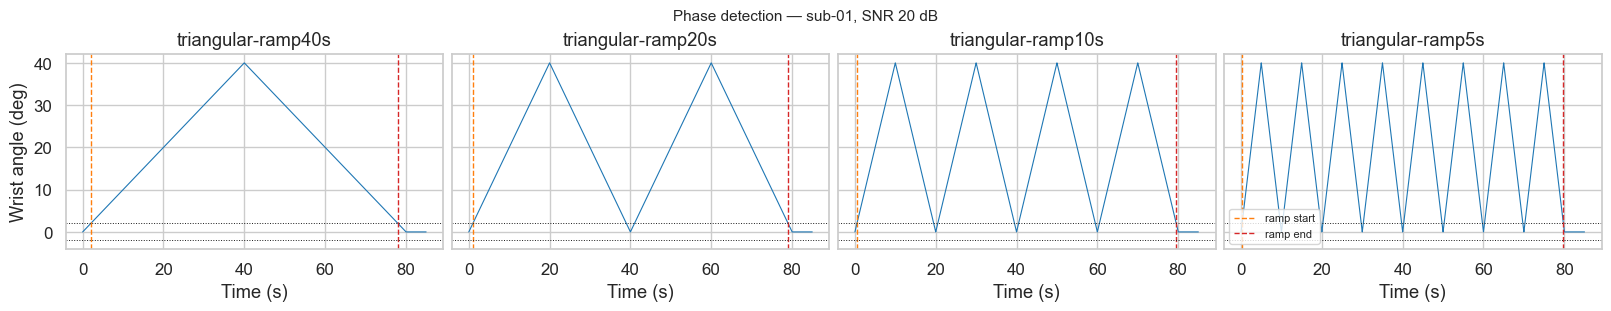

In [10]:
# Sanity check: plot angle profiles and detected phase boundaries for one subject
sub_check = 'sub-01'
snr_check = 20
n_tri     = len(TRIANGULAR)

fig, axs = plt.subplots(1, n_tri, figsize=(4 * n_tri, 3), layout='constrained', sharey=True)
for ax, cond in zip(axs, TRIANGULAR):
    key     = (sub_check, cond, snr_check)
    angle   = results[key]['angle_adapt']
    t       = np.arange(len(angle)) / FS
    phases  = detect_triangular_phases(angle)
    ax.plot(t, angle, color='tab:blue', linewidth=0.8)
    ax.axvline(phases['ramp_start'] / FS, color='tab:orange', linestyle='--',
               linewidth=1, label='ramp start')
    ax.axvline(phases['ramp_end'] / FS, color='tab:red', linestyle='--',
               linewidth=1, label='ramp end')
    ax.axhline(ANGLE_ISO_THR_DEG,  color='k', linestyle=':', linewidth=0.7)
    ax.axhline(-ANGLE_ISO_THR_DEG, color='k', linestyle=':', linewidth=0.7)
    ax.set(title=cond, xlabel='Time (s)')
axs[0].set_ylabel('Wrist angle (deg)')
axs[-1].legend(fontsize=8)
plt.suptitle(f'Phase detection — {sub_check}, SNR {snr_check} dB', fontsize=11)
plt.show()

In [11]:
PHASE_ORDER  = ['first_iso', 'ramp', 'last_iso']
PHASE_LABELS = {
    'first_iso': 'First isometric',
    'ramp':      'Triangular ramp',
    'last_iso':  'Last isometric',
}

phase_rows = []
for (sub, cond, snr), res in results.items():
    if cond not in TRIANGULAR:
        continue
    phases = detect_triangular_phases(res['angle_adapt'])
    for phase_name in PHASE_ORDER:
        idx = phases[phase_name]
        roa = compute_roa_subset(res['gt_bin'], res['spikes'], idx)
        for u, r in enumerate(roa):
            phase_rows.append({
                'sub':       sub,
                'condition': cond,
                'snr':       snr,
                'phase':     phase_name,
                'unit':      u,
                'roa':       float(r),
            })

df_phase = pd.DataFrame(phase_rows)
df_phase['roa_pct'] = df_phase['roa'] * 100
df_phase['phase']   = pd.Categorical(df_phase['phase'],
                                     categories=PHASE_ORDER, ordered=True)
print(f'Phase-RoA rows: {len(df_phase)}')

Phase-RoA rows: 1734


In [12]:
# Summary tables: one per triangular condition
for cond in TRIANGULAR:
    df_c = df_phase[df_phase['condition'] == cond]
    tbl  = (
        df_c.groupby(['snr', 'phase'], observed=True)['roa_pct']
        .agg(['mean', 'std'])
        .round(2)
        .unstack('phase')
    )
    tbl.columns = [f'{m} ({p})' for m, p in tbl.columns]
    # Reorder: mean cols then std cols, grouped by phase
    col_order = [f'{m} ({p})'
                 for p in PHASE_ORDER
                 for m in ['mean', 'std']]
    tbl = tbl[[c for c in col_order if c in tbl.columns]]
    print(f'\n=== {cond} ===')
    print(tbl.to_string())
    print()


=== triangular-ramp40s ===
     mean (first_iso)  std (first_iso)  mean (ramp)  std (ramp)  mean (last_iso)  std (last_iso)
snr                                                                                             
15              92.32             9.92        41.13       19.49            79.27           11.64
20              93.53             9.30        42.19       17.51            84.71           11.05
25              92.95             7.37        38.21       16.41            87.04           11.02
30              91.07            10.58        36.26       17.02            90.43           12.24


=== triangular-ramp20s ===
     mean (first_iso)  std (first_iso)  mean (ramp)  std (ramp)  mean (last_iso)  std (last_iso)
snr                                                                                             
15              86.44            16.41        44.81       22.69            80.29           14.18
20              89.75            13.73        41.46       17.07       

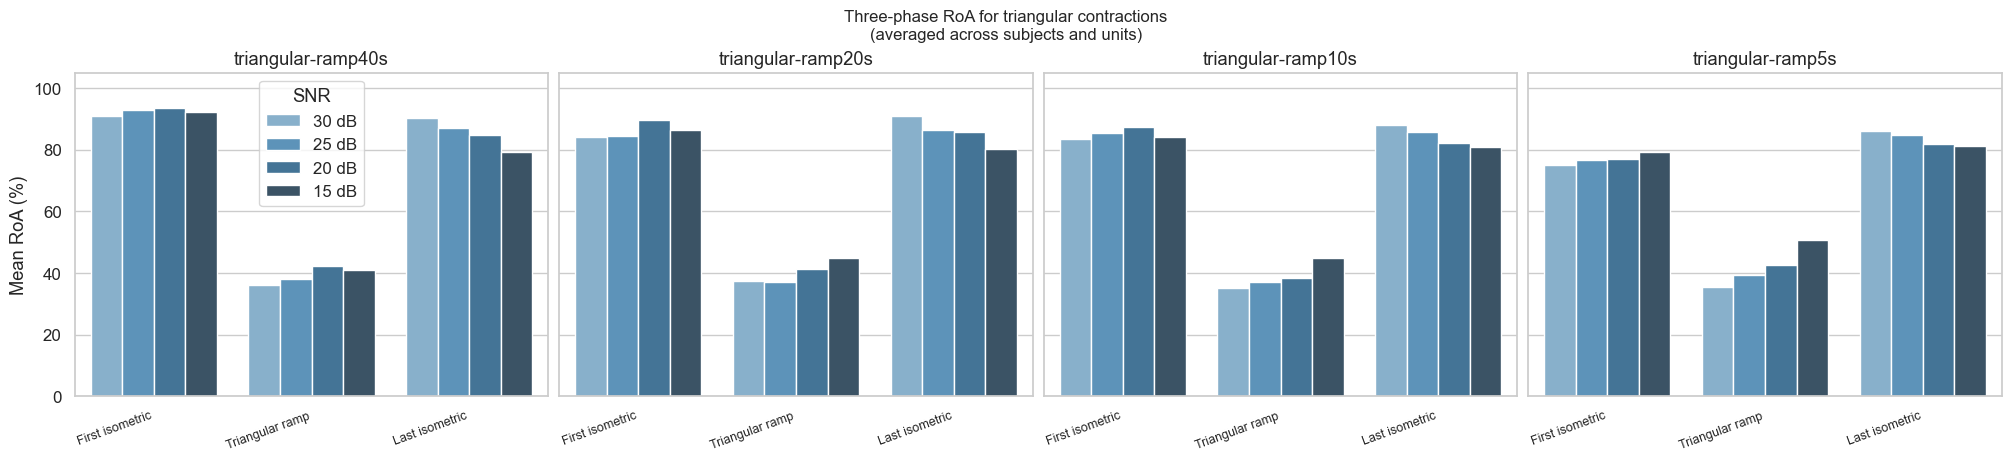

In [13]:
# Phase bar chart: one subplot per triangular condition
fig, axs = plt.subplots(1, n_tri, figsize=(5 * n_tri, 4.5),
                         layout='constrained', sharey=True)

for ax, cond in zip(axs, TRIANGULAR):
    df_c = df_phase[df_phase['condition'] == cond]
    mean_df = (
        df_c.groupby(['snr', 'phase'], observed=True)['roa_pct']
        .mean()
        .reset_index()
    )
    mean_df['SNR'] = mean_df['snr'].astype(str) + ' dB'
    sns.barplot(
        data=mean_df, x='phase', y='roa_pct', hue='SNR',
        hue_order=snr_order, order=PHASE_ORDER,
        palette='Blues_d', ax=ax,
    )
    ax.set(
        xlabel='', ylabel='Mean RoA (%)',
        title=cond, ylim=(0, 105),
    )
    ax.set_xticks(range(len(PHASE_ORDER)))
    ax.set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER],
                       rotation=20, ha='right', fontsize=9)
    if ax != axs[0]:
        ax.set_ylabel('')
        ax.get_legend().remove()

axs[0].set_ylabel('Mean RoA (%)')
plt.suptitle(
    'Three-phase RoA for triangular contractions\n'
    '(averaged across subjects and units)',
    fontsize=12,
)
plt.show()

## 5. Summary figure

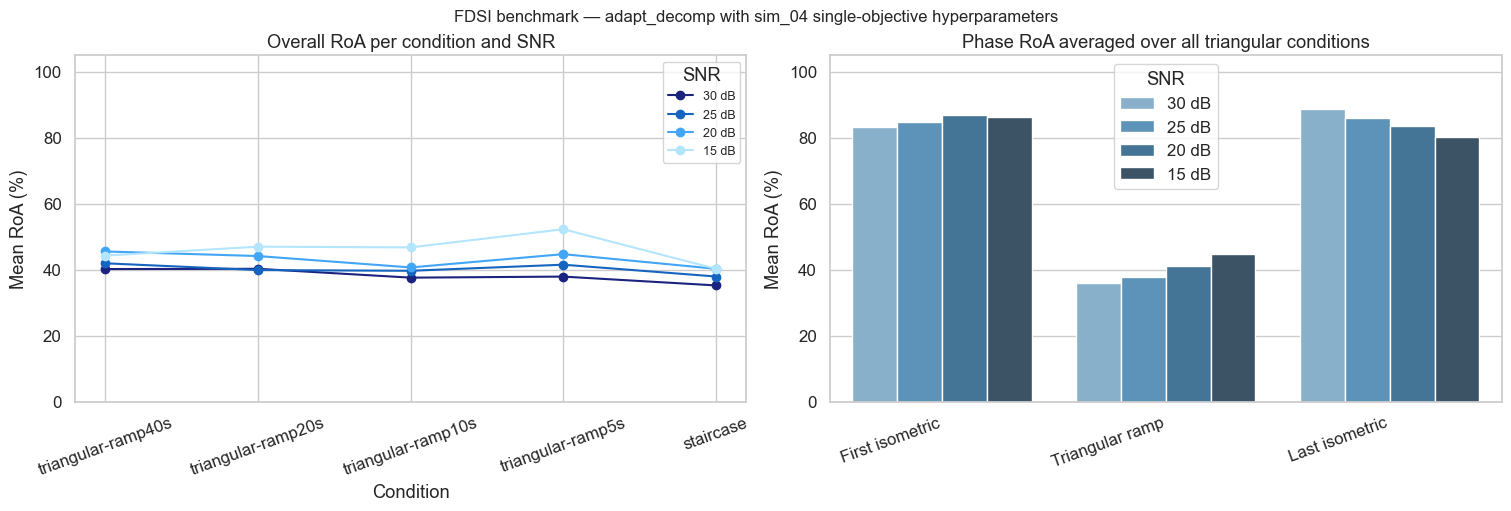

In [14]:
colors_snr = {30: '#1a237e', 25: '#1565c0', 20: '#42a5f5', 15: '#b3e5fc'}

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

# ── Left: overall mean RoA per condition, one line per SNR ────────────────────
mean_by = df.groupby(['condition', 'snr'])['roa_pct'].mean().reset_index()
for snr in SNR_LEVELS:
    sub_df = mean_by[mean_by['snr'] == snr].set_index('condition').reindex(CONDITIONS)
    axs[0].plot(
        CONDITIONS, sub_df['roa_pct'],
        marker='o', label=f'{snr} dB', color=colors_snr[snr],
    )
axs[0].set(
    ylabel='Mean RoA (%)',
    title='Overall RoA per condition and SNR',
    ylim=(0, 105),
    xlabel='Condition',
)
axs[0].tick_params(axis='x', rotation=20)
axs[0].legend(title='SNR', fontsize=9)

# ── Right: three-phase RoA averaged over all triangular conditions ─────────────
phase_mean = (
    df_phase.groupby(['snr', 'phase'], observed=True)['roa_pct']
    .mean()
    .reset_index()
)
phase_mean['SNR'] = phase_mean['snr'].astype(str) + ' dB'
sns.barplot(
    data=phase_mean, x='phase', y='roa_pct', hue='SNR',
    hue_order=snr_order, order=PHASE_ORDER,
    palette='Blues_d', ax=axs[1],
)
axs[1].set_xticks(range(len(PHASE_ORDER)))
axs[1].set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER],
                        rotation=20, ha='right')
axs[1].set(
    ylabel='Mean RoA (%)',
    title='Phase RoA averaged over all triangular conditions',
    ylim=(0, 105),
    xlabel='',
)

plt.suptitle(
    'FDSI benchmark — adapt_decomp with sim_04 single-objective hyperparameters',
    fontsize=12,
)
plt.show()